# Passive Ownership & Price Efficiency — STOXX Europe 600
## Complete Data Walkthrough

This notebook walks through the full empirical pipeline step by step, from raw STOXX constituent files all the way to the feature matrix used for causal identification. It is designed to give an outsider a clear visual understanding of what the data looks like, what decisions were made, and why.

**Research question:** Does being added to a major passive index (STOXX Europe 600) causally reduce the price efficiency of the included stock?

**Pipeline overview:**
1. Parse STOXX monthly snapshots → detect ADD / DELETE events
2. Download daily prices via Yahoo Finance
3. Build monthly panel of market efficiency metrics (Synchronicity, Idio_Vol, Amihud)
4. Compute pre-event characteristics for Propensity Score Matching
5. Run stacked Difference-in-Differences

In [2]:
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
%matplotlib inline

sns.set_theme(style='whitegrid', context='notebook', font_scale=1.15)
plt.rcParams.update({
    'font.family': 'serif',
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

ROOT = Path('../')
print('Setup OK')

Setup OK


In [3]:
# ── Load all intermediate datasets ──────────────────────────────────────────
events   = pd.read_csv(ROOT / 'data/intermediate/events.csv')
events['date'] = pd.to_datetime(events['date'])

panel    = pd.read_parquet(ROOT / 'data/intermediate/panel_monthly.parquet')
panel['date'] = pd.to_datetime(panel['date'])


prices   = pd.read_parquet(ROOT / 'data/intermediate/prices_raw.parquet')
prices['date'] = pd.to_datetime(prices['date'])

features = pd.read_csv(ROOT / 'data/intermediate/features_at_event.csv')
features['event_date'] = pd.to_datetime(features['event_date'])

prices   = pd.read_parquet(ROOT / 'data/intermediate/prices_raw.parquet')
prices['date'] = pd.to_datetime(prices['date'])

print(f'Events      : {len(events):>8,} rows  |  {events["date"].nunique()} unique dates')
print(f'Panel       : {len(panel):>8,} rows  |  {panel["ticker"].nunique()} tickers')
print(f'Features    : {len(features):>8,} rows  |  {features["event_date"].nunique()} events')
print(f'Prices raw  : {len(prices):>8,} rows  |  {prices["ticker"].nunique()} tickers')

Events      :    1,874 rows  |  82 unique dates
Panel       :  132,652 rows  |  1033 tickers
Features    :  894,866 rows  |  82 events
Prices raw  : 2,931,958 rows  |  1035 tickers


---
## Part 1 — Raw Source Files: STOXX Monthly Snapshots

The raw data are official **STOXX monthly constituent files** (`slpublic_sxxp_YYYYMMDD.csv`) — one file per month from November 2015 to February 2026. Each file lists all securities ranked by STOXX at that date, with their current rank (`Rank (FINAL)`) and previous rank (`Rank (PREVIOUS)`).

**Key challenge:** Files predating November 2023 were generated from quarterly PDF reviews. The PDF-to-CSV conversion introduced two types of garbage rows that had to be detected and removed before any analysis.

In [4]:
raw_files = sorted(glob.glob(str(ROOT / 'data/raw/inclusions/slpublic_sxxp_*.csv')))
print(f'Total raw CSV files : {len(raw_files)}')
print(f'Earliest            : {Path(raw_files[0]).stem}')
print(f'Latest              : {Path(raw_files[-1]).stem}')

# Show a sample of the raw file (a 2023 clean one)
sample_clean = [f for f in raw_files if '20231101' in f]
if sample_clean:
    df_clean = pd.read_csv(sample_clean[0], sep=';', dtype=str)
    print(f'\n--- Clean file (Nov 2023): {len(df_clean)} rows, {len(df_clean.columns)} columns ---')
    print('Columns:', df_clean.columns.tolist())
    display(df_clean[['RIC', 'Instrument_Name', 'Country', 'Rank (FINAL)', 'Rank (PREVIOUS)']].head(8))

Total raw CSV files : 102
Earliest            : slpublic_sxxp_20151001
Latest              : slpublic_sxxp_20260202

--- Clean file (Nov 2023): 1853 rows, 18 columns ---
Columns: ['Creation_Date', 'Index_Symbol', 'Index_Name', 'Index ISIN', 'Internal_Key', 'ISIN', 'RIC', 'Instrument_Name', 'Country', 'Currency', 'Exchange', 'Index Membership', 'FF Mcap (MEUR)', 'Rank (FINAL)', 'Rank (PREVIOUS)', 'Comment', 'Rank 2 (FINAL)', 'Rank 2 (PREVIOUS)']


,RIC,Instrument_Name,Country,Rank (FINAL),Rank (PREVIOUS)
0,NOVOb.CO,NOVO NORDISK B,DK,1,2
1,NESN.S,NESTLE,CH,2,1
2,ASML.AS,ASML HLDG,NL,3,3
3,SHEL.AS,SHELL,GB,4,4
4,AZN.L,ASTRAZENECA,GB,5,6
5,NOVN.S,NOVARTIS,CH,6,5
6,LVMH.PA,LVMH MOET HENNESSY,FR,7,7
7,ROG.S,ROCHE HLDG P,CH,8,8


In [5]:
# Show what a corrupted pre-2021 file looks like (a quarterly file)
sample_bad = [f for f in raw_files if '20170101' in f]
if sample_bad:
    df_bad = pd.read_csv(sample_bad[0], sep=';', dtype=str)
    print(f'--- Corrupted quarterly file (Jan 2017): {len(df_bad)} rows ---')
    print('Unique Rank (FINAL) values:', sorted(df_bad['Rank (FINAL)'].dropna().unique()[:20].tolist()))
    print('\nSample rows showing PDF artifact (rank 0-9 repeated):')
    display(df_bad[df_bad['Rank (FINAL)'].isin(['1','2','3','4','5'])]
            [['RIC','Instrument_Name','Rank (FINAL)','Rank (PREVIOUS)']].head(12))

--- Corrupted quarterly file (Jan 2017): 1067 rows ---
Unique Rank (FINAL) values: ['0', '1', '177', '2', '269', '3', '361', '4', '453', '5', '545', '6', '637', '7', '729', '8', '821', '85', '9', '913']

Sample rows showing PDF artifact (rank 0-9 repeated):


,RIC,Instrument_Name,Rank (FINAL),Rank (PREVIOUS)
0,NESN.S,NESTLE,1,1
2,HSBA.L,HSBC,5,3
3,ROG.S,RO E HLDG P,4,4
4,TOTF.PA,BC TOTAL,2,5
8,SIEGn.DE,SIEGn. SIEMENS,3,9
9,SASY.PA,SANOFI,3,10
10,GSK.L,GLAXOSMITHKLINE,2,11
13,BASFn.DE,BASFn. BASF,1,14
15,SAN.MC,BCO SANTANDER,3,16
17,DAIGn.DE,DAIGn. DAIMLER,5,18


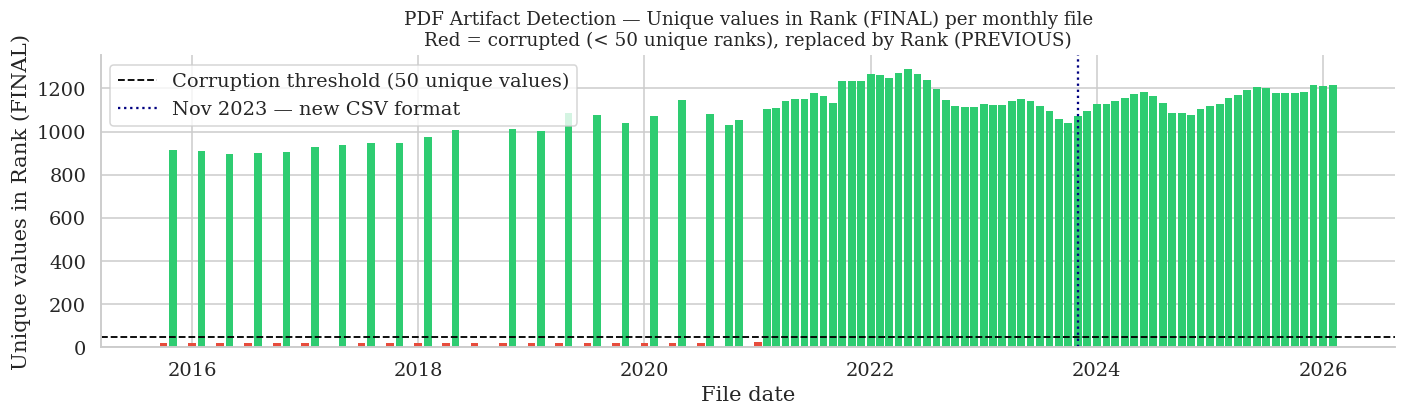

Corrupted files detected: 20 / 102


In [6]:
# Visualise the artifact problem: count of unique Rank (FINAL) values per file
n_unique = []
for f in raw_files:
    df = pd.read_csv(f, sep=';', dtype=str)
    date_str = Path(f).stem.split('_')[-1]
    yr = int(date_str[:4]); mo = int(date_str[4:6])
    n = pd.to_numeric(df['Rank (FINAL)'], errors='coerce').nunique()
    n_unique.append({'date': pd.Timestamp(yr, mo, 1), 'n_unique': n})

uniq_df = pd.DataFrame(n_unique).sort_values('date')

fig, ax = plt.subplots(figsize=(13, 4))
colors = ['#e74c3c' if n < 50 else '#2ecc71' for n in uniq_df['n_unique']]
ax.bar(uniq_df['date'], uniq_df['n_unique'], color=colors, width=25, edgecolor='none')
ax.axhline(50, color='black', lw=1.2, linestyle='--', label='Corruption threshold (50 unique values)')
ax.axvline(pd.Timestamp('2023-11-01'), color='navy', lw=1.5, linestyle=':', label='Nov 2023 — new CSV format')
ax.set_xlabel('File date')
ax.set_ylabel('Unique values in Rank (FINAL)')
ax.set_title('PDF Artifact Detection — Unique values in Rank (FINAL) per monthly file\nRed = corrupted (< 50 unique ranks), replaced by Rank (PREVIOUS)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

n_corrupt = (uniq_df['n_unique'] < 50).sum()
print(f'Corrupted files detected: {n_corrupt} / {len(uniq_df)}')

---
## Part 2 — Event Detection: Index Inclusions & Exclusions

An **ADD** event occurs when a stock's rank crosses *into* the index:
$$\text{rank\_prev} > 600 \quad \land \quad \text{rank\_final} \leq 600$$

A **DELETE** event is the mirror transition. These are the shocks we use for causal identification — a stock being added to the index suddenly faces much higher passive ownership from index-tracking ETFs and funds.

In [7]:
print('=== Event counts ===')
print(events['event_type'].value_counts().to_string())
print(f'\nDate range : {events["date"].min().date()} → {events["date"].max().date()}')
print(f'Countries  : {events["Country"].nunique()}')
print(f'Unique ADD tickers : {events[events["event_type"]=="ADD"]["ticker"].nunique()}')
print()
display(events.head(6))

=== Event counts ===
event_type
ADD       953
DELETE    921

Date range : 2015-11-03 → 2026-02-02
Countries  : 17
Unique ADD tickers : 434



,date,ISIN,ticker,name,Country,event_type,rank_final,rank_prev,ric
0,2015-11-03,GB00B1FP8915,BBA.L,BFP BBA AVIATION,GB,ADD,504,636,BBA.L
1,2015-11-03,CH0267291224,SRCG.SW,BVSS Z SUNRISE,CH,DELETE,632,600,SRCG.S
2,2015-11-03,DK0060477503,TOP.CO,BP TOPDANMARK,DK,DELETE,625,585,TOP.CO
3,2015-11-03,GRS419003009,OPAr.AT,OPAr. OPAP GR,AT,DELETE,622,599,OPAr.AT
4,2015-11-03,GB00B3Y2J508,GFRD.L,BYJ A GALLIFORD TRY,GB,DELETE,621,588,GFRD.L
5,2015-11-03,GB00BLT1Y088,SAGAG.L,BLTY C SAGA,GB,DELETE,607,598,SAGAG.L


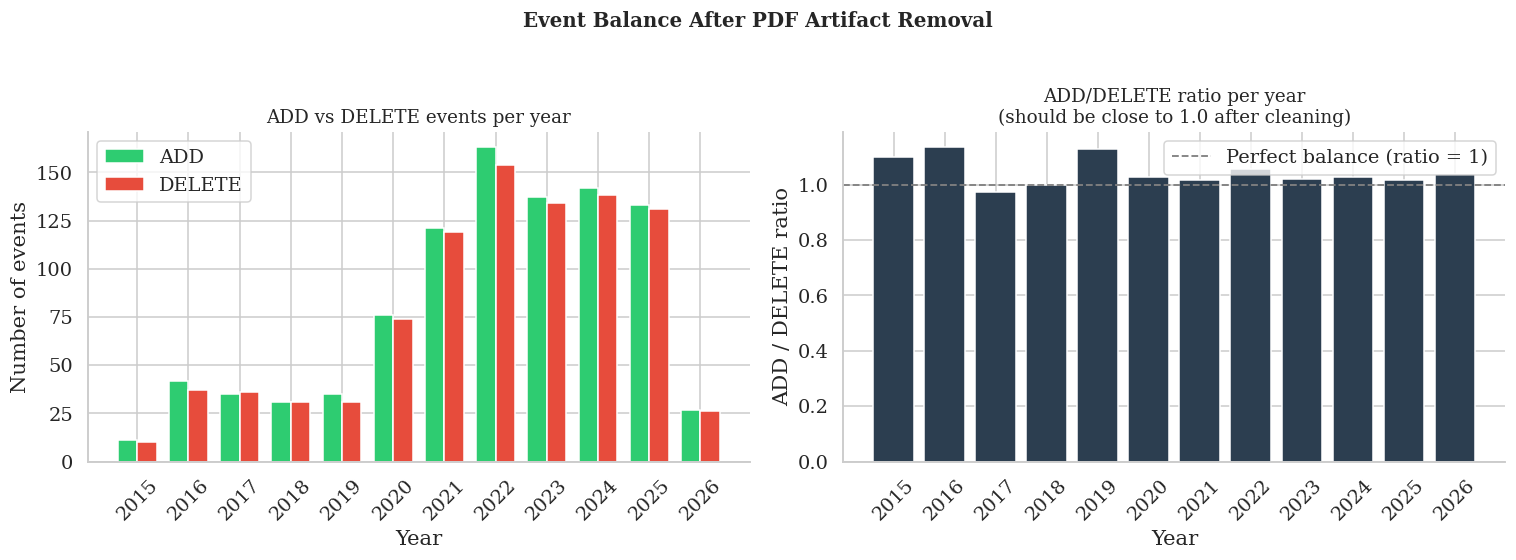

In [8]:
# ADD vs DELETE by year
events['year'] = events['date'].dt.year
by_year = events.groupby(['year', 'event_type']).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart ADD vs DELETE per year
ax = axes[0]
x = np.arange(len(by_year))
w = 0.38
bars_add = ax.bar(x - w/2, by_year.get('ADD', 0), w, label='ADD', color='#2ecc71', edgecolor='white')
bars_del = ax.bar(x + w/2, by_year.get('DELETE', 0), w, label='DELETE', color='#e74c3c', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(by_year.index, rotation=45)
ax.set_xlabel('Year')
ax.set_ylabel('Number of events')
ax.set_title('ADD vs DELETE events per year', fontsize=12)
ax.legend()

# Ratio ADD/DELETE
ax2 = axes[1]
ratio = by_year.get('ADD', 0) / by_year.get('DELETE', 1).replace(0, np.nan)
colors_ratio = ['#e74c3c' if r > 2 or r < 0.5 else '#2c3e50' for r in ratio]
ax2.bar(x, ratio, color=colors_ratio, edgecolor='white')
ax2.axhline(1.0, color='grey', lw=1.2, linestyle='--', label='Perfect balance (ratio = 1)')
ax2.set_xticks(x)
ax2.set_xticklabels(by_year.index, rotation=45)
ax2.set_xlabel('Year')
ax2.set_ylabel('ADD / DELETE ratio')
ax2.set_title('ADD/DELETE ratio per year\n(should be close to 1.0 after cleaning)', fontsize=12)
ax2.legend()

plt.suptitle('Event Balance After PDF Artifact Removal', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

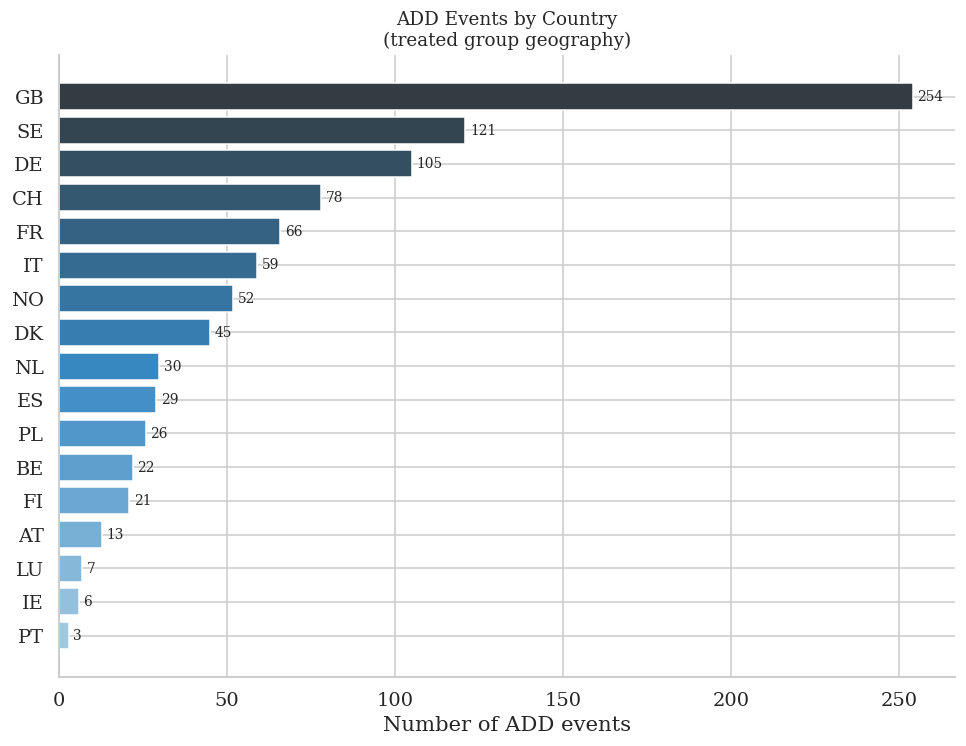

In [9]:
# Geographic distribution of ADD events
add_by_country = (events[events['event_type'] == 'ADD']
                  .groupby('Country').size()
                  .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(9, 7))
colors_geo = sns.color_palette('Blues_d', len(add_by_country))
bars = ax.barh(add_by_country.index, add_by_country.values, color=colors_geo, edgecolor='white')
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel('Number of ADD events')
ax.set_title('ADD Events by Country\n(treated group geography)', fontsize=12)
plt.tight_layout()
plt.show()

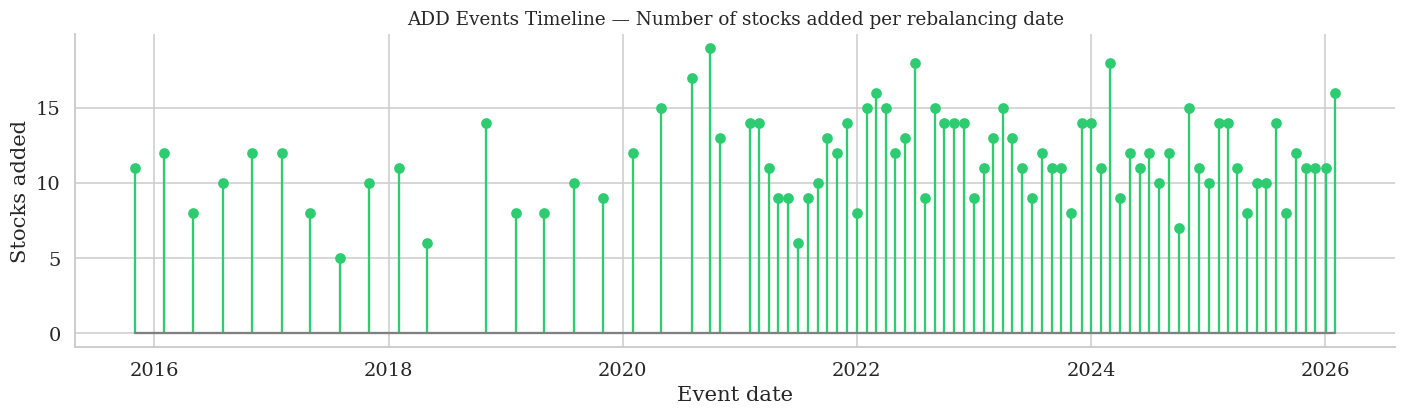

Unique event dates   : 82
Avg stocks per event : 11.6
Max stocks per event : 19


In [10]:
# Timeline: unique ADD event dates
add_events = events[events['event_type'] == 'ADD'].copy()
add_timeline = add_events.groupby('date').size().reset_index(name='n_stocks')

fig, ax = plt.subplots(figsize=(13, 4))
ax.stem(add_timeline['date'], add_timeline['n_stocks'],
        linefmt='#2ecc71', markerfmt='o', basefmt='grey')
ax.set_xlabel('Event date')
ax.set_ylabel('Stocks added')
ax.set_title('ADD Events Timeline — Number of stocks added per rebalancing date', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Unique event dates   : {add_timeline["date"].nunique()}')
print(f'Avg stocks per event : {add_timeline["n_stocks"].mean():.1f}')
print(f'Max stocks per event : {add_timeline["n_stocks"].max()}')

---
## Part 3 — Price Data: Coverage & Quality

Daily adjusted prices and volumes are downloaded from **Yahoo Finance** for all ADD-event tickers and a large pool of stable tickers (potential controls). This section checks the coverage and quality of the price data.

**Key challenge:** STOXX files use Reuters Instrument Codes (RICs), which differ from Yahoo Finance identifiers. A systematic remapping layer was applied (manual dictionary + regex for Swiss `.S→.SW` and Nordic class-B hyphenation).

In [11]:
obs_per_ticker = prices.groupby('ticker')['date'].count().sort_values()

print(f'Total price observations : {len(prices):,}')
print(f'Unique tickers           : {prices["ticker"].nunique()}')
print(f'Date range               : {prices["date"].min().date()} → {prices["date"].max().date()}')
print(f'Median obs per ticker    : {obs_per_ticker.median():.0f} days')
print(f'Tickers < 252 obs (< 1y) : {(obs_per_ticker < 252).sum()}')
print(f'Tickers >= 2520 obs (10y): {(obs_per_ticker >= 2520).sum()}')

Total price observations : 2,931,958
Unique tickers           : 1035
Date range               : 2013-01-01 → 2026-02-27
Median obs per ticker    : 3304 days
Tickers < 252 obs (< 1y) : 5
Tickers >= 2520 obs (10y): 776


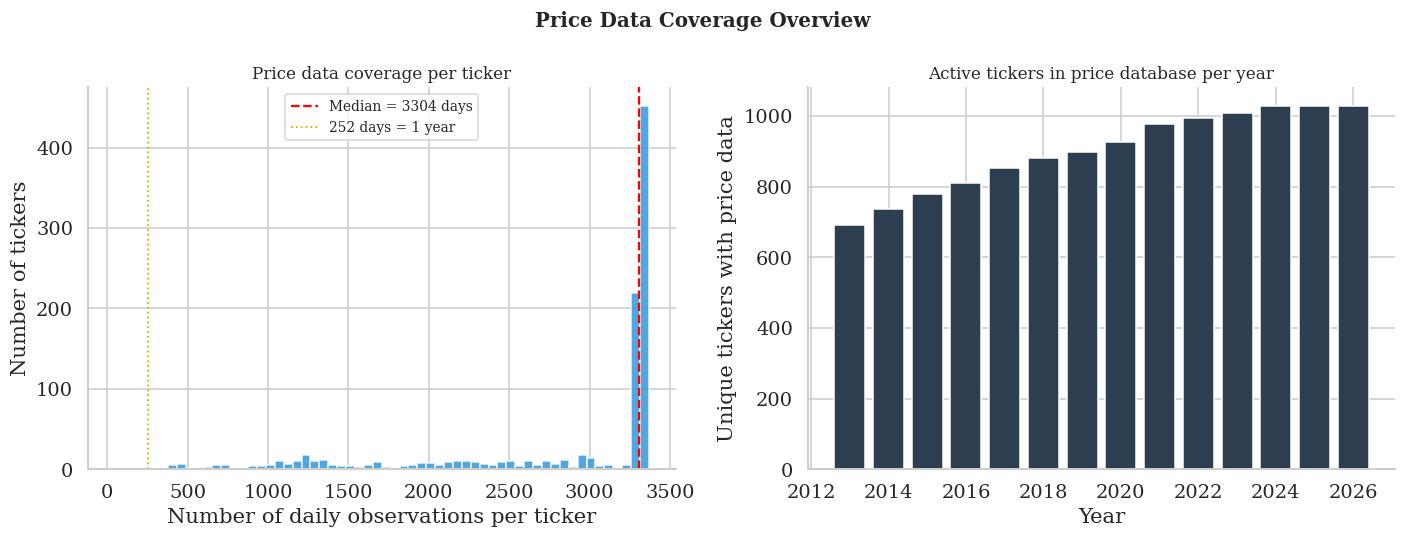

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribution of observations per ticker
ax = axes[0]
ax.hist(obs_per_ticker.values, bins=60, color='#3498db', edgecolor='white', alpha=0.85)
ax.axvline(obs_per_ticker.median(), color='red', lw=1.5, linestyle='--',
           label=f'Median = {obs_per_ticker.median():.0f} days')
ax.axvline(252, color='orange', lw=1.2, linestyle=':', label='252 days = 1 year')
ax.set_xlabel('Number of daily observations per ticker')
ax.set_ylabel('Number of tickers')
ax.set_title('Price data coverage per ticker', fontsize=11)
ax.legend(fontsize=9)

# Number of tickers priced each year
ax2 = axes[1]
prices['year'] = prices['date'].dt.year
tickers_per_year = prices.groupby('year')['ticker'].nunique()
ax2.bar(tickers_per_year.index, tickers_per_year.values, color='#2c3e50', edgecolor='white')
ax2.set_xlabel('Year')
ax2.set_ylabel('Unique tickers with price data')
ax2.set_title('Active tickers in price database per year', fontsize=11)

plt.suptitle('Price Data Coverage Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "notebook"

# 1. Préparation des données de couverture
tickers_with_data = set(prices['ticker'].unique())
add_ev = events[events['event_type'] == 'ADD'].copy()
add_ev['has_data'] = add_ev['ticker'].isin(tickers_with_data)

coverage = add_ev.groupby('Country')['has_data'].agg(
    total='count', 
    with_data='sum'
).assign(pct=lambda d: 100 * d['with_data'] / d['total']).reset_index()

# 2. Mapping Alpha-2 -> ISO-3
iso_mapping = {
    'AT': 'AUT', 'BE': 'BEL', 'CH': 'CHE', 'DE': 'DEU', 'DK': 'DNK',
    'ES': 'ESP', 'FI': 'FIN', 'FR': 'FRA', 'GB': 'GBR', 'IE': 'IRL',
    'IT': 'ITA', 'LU': 'LUX', 'NL': 'NLD', 'NO': 'NOR', 'PL': 'POL',
    'PT': 'PRT', 'SE': 'SWE'
}
coverage["iso_a3"] = coverage["Country"].map(iso_mapping)

# 3. Création de la carte de couverture
fig = px.choropleth(
    coverage,
    locations="iso_a3",
    locationmode="ISO-3",
    color="pct",
    scope="europe",
    # Échelle de couleur allant du rouge au vert (RdYlGn)
    color_continuous_scale="RdYlGn",
    range_color=[70, 100], # On centre sur la zone critique
    title="Price Data Coverage by Country (ADD Events)",
    labels={"pct": "Coverage (%)", "iso_a3": "Country"},
    hover_data={"Country": True, "total": True, "with_data": True, "pct": ":.1f%"},
    height=600,
)

# 4. Ajustements esthétiques
fig.update_geos(
    showcoastlines=True,
    showland=True,
    landcolor="#f8f8f8",
    showocean=True,
    oceancolor="#e8f4f8",
    showcountries=True,
    countrycolor="#bbbbbb",
)

fig.update_layout(
    title_x=0.5, 
    font_family="serif",
    coloraxis_colorbar=dict(
        title="Coverage %",
        ticksuffix="%",
        thickness=15
    )
)

fig.show()

---
## Part 4 — Monthly Efficiency Panel

For each `(ticker, month)` with at least 15 daily observations, a **market model OLS** regression is fitted:
$$r_{i,t} = \alpha_i + \beta_i \cdot r_{m,t} + \varepsilon_{i,t}$$

Four efficiency metrics are computed from this regression:

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **Synchronicity** | $\ln(R^2 / (1 - R^2))$ | Co-movement with market. Higher → less firm-specific info in prices |
| **Idio_Vol** | $\sigma(\hat{\varepsilon})$ | Idiosyncratic volatility. Higher → more firm-specific variation |
| **Amihud** | $\overline{|r_t| / (P_t V_t)} \times 10^6$ | Illiquidity. Higher → price moves more per dollar traded |
| **Avg_Volume** | $\overline{V_t}$ | Average daily trading volume |

**Note on interpretation:** Synchronicity and Idio_Vol are inversely related. If index inclusion reduces price efficiency (less firm-specific information incorporated), we expect **Synchronicity ↑** and **Idio_Vol ↓**.

In [14]:
print('=== Panel Monthly — Descriptive Statistics ===')
desc = panel[['Synchronicity', 'Idio_Vol', 'Amihud', 'Avg_Volume']].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).round(4)
display(desc)

=== Panel Monthly — Descriptive Statistics ===


,Synchronicity,Idio_Vol,Amihud,Avg_Volume
count,132652.0000,132652.0000,132652.0000,1.326520e+05
mean,-2.2200,0.0187,0.9966,1.946441e+06
std,1.9564,0.0140,32.7064,9.521611e+06
min,-6.9068,0.0000,0.0000,2.570000e+00
1%,-6.9068,0.0053,0.0000,6.511367e+02
5%,-6.5516,0.0072,0.0000,3.571430e+03
25%,-3.3023,0.0112,0.0002,5.226950e+04
50%,-1.8577,0.0155,0.0018,2.396530e+05
75%,-0.7965,0.0220,0.0144,9.451942e+05
95%,0.3935,0.0395,0.5506,6.583702e+06


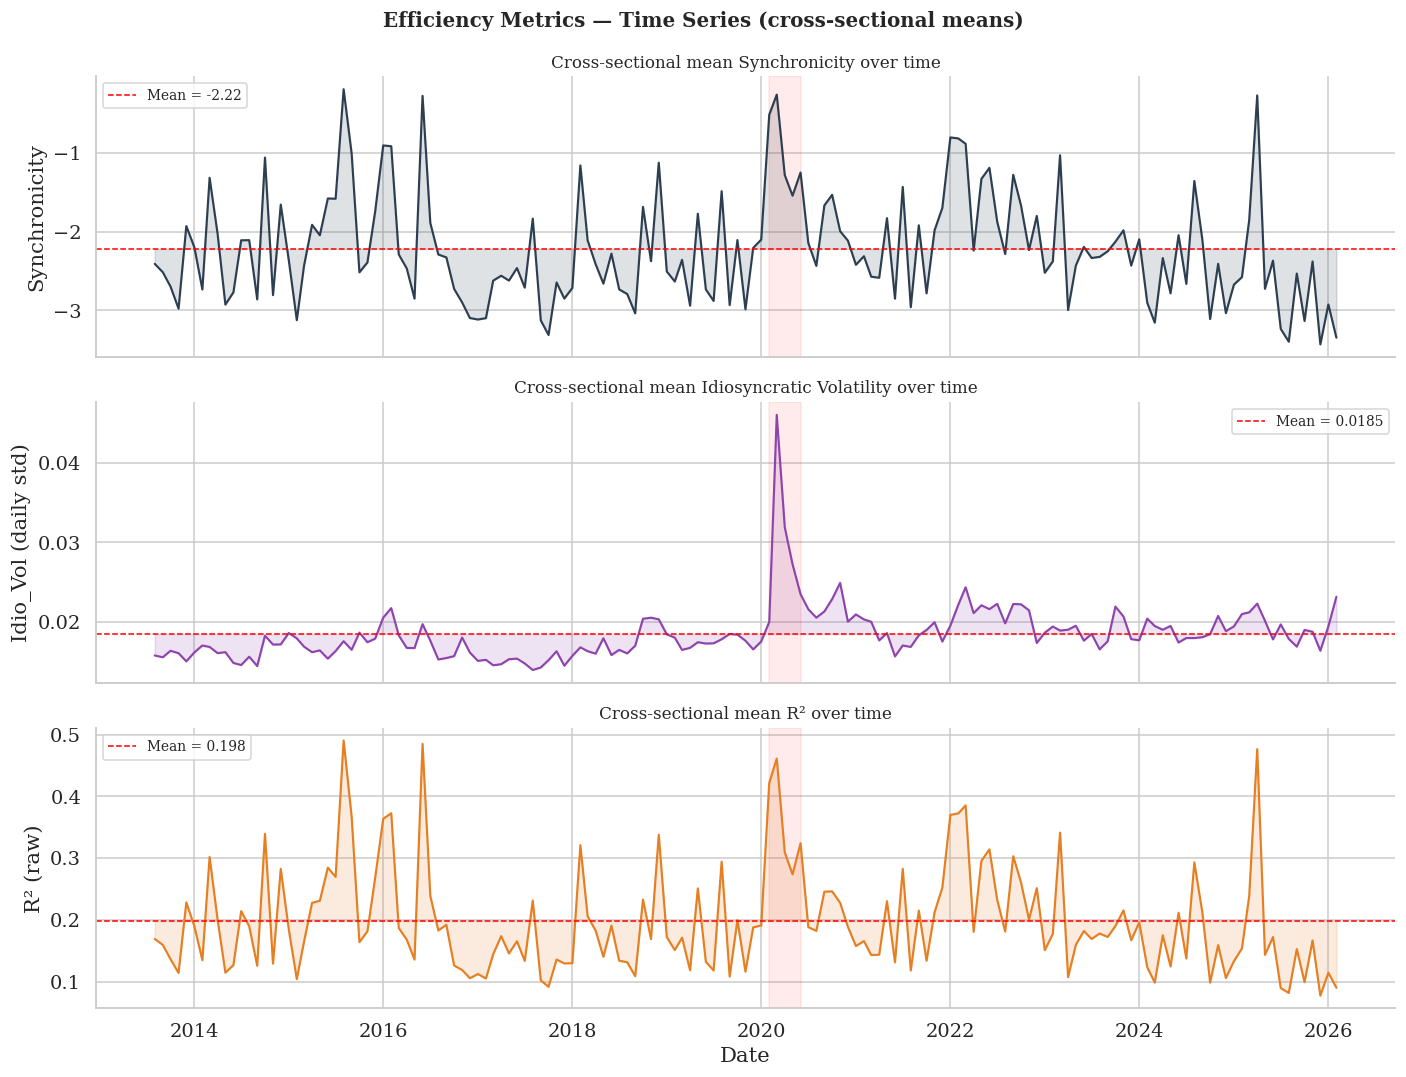

In [15]:
# Time series: mean Synchronicity and mean Idio_Vol over time
monthly_mean = panel.groupby('date')[['Synchronicity', 'Idio_Vol', 'R2_raw']].mean()

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

# Synchronicity
ax = axes[0]
ax.plot(monthly_mean.index, monthly_mean['Synchronicity'], color='#2c3e50', lw=1.4)
ax.axhline(monthly_mean['Synchronicity'].mean(), color='red', lw=1, linestyle='--',
           label=f'Mean = {monthly_mean["Synchronicity"].mean():.2f}')
ax.fill_between(monthly_mean.index, monthly_mean['Synchronicity'].mean(),
                monthly_mean['Synchronicity'], alpha=0.15, color='#2c3e50')
ax.set_ylabel('Synchronicity')
ax.set_title('Cross-sectional mean Synchronicity over time', fontsize=11)
ax.legend(fontsize=9)

# Idio_Vol
ax2 = axes[1]
ax2.plot(monthly_mean.index, monthly_mean['Idio_Vol'], color='#8e44ad', lw=1.4)
ax2.axhline(monthly_mean['Idio_Vol'].mean(), color='red', lw=1, linestyle='--',
            label=f'Mean = {monthly_mean["Idio_Vol"].mean():.4f}')
ax2.fill_between(monthly_mean.index, monthly_mean['Idio_Vol'].mean(),
                 monthly_mean['Idio_Vol'], alpha=0.15, color='#8e44ad')
ax2.set_ylabel('Idio_Vol (daily std)')
ax2.set_title('Cross-sectional mean Idiosyncratic Volatility over time', fontsize=11)
ax2.legend(fontsize=9)

# R² raw
ax3 = axes[2]
ax3.plot(monthly_mean.index, monthly_mean['R2_raw'], color='#e67e22', lw=1.4)
ax3.axhline(monthly_mean['R2_raw'].mean(), color='red', lw=1, linestyle='--',
            label=f'Mean = {monthly_mean["R2_raw"].mean():.3f}')
ax3.fill_between(monthly_mean.index, monthly_mean['R2_raw'].mean(),
                 monthly_mean['R2_raw'], alpha=0.15, color='#e67e22')
ax3.set_ylabel('R² (raw)')
ax3.set_xlabel('Date')
ax3.set_title('Cross-sectional mean R² over time', fontsize=11)
ax3.legend(fontsize=9)

# Add COVID shading
covid_start = pd.Timestamp('2020-02-01')
covid_end   = pd.Timestamp('2020-06-01')
for ax_ in axes:
    ax_.axvspan(covid_start, covid_end, alpha=0.08, color='red', label='COVID-19')

plt.suptitle('Efficiency Metrics — Time Series (cross-sectional means)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

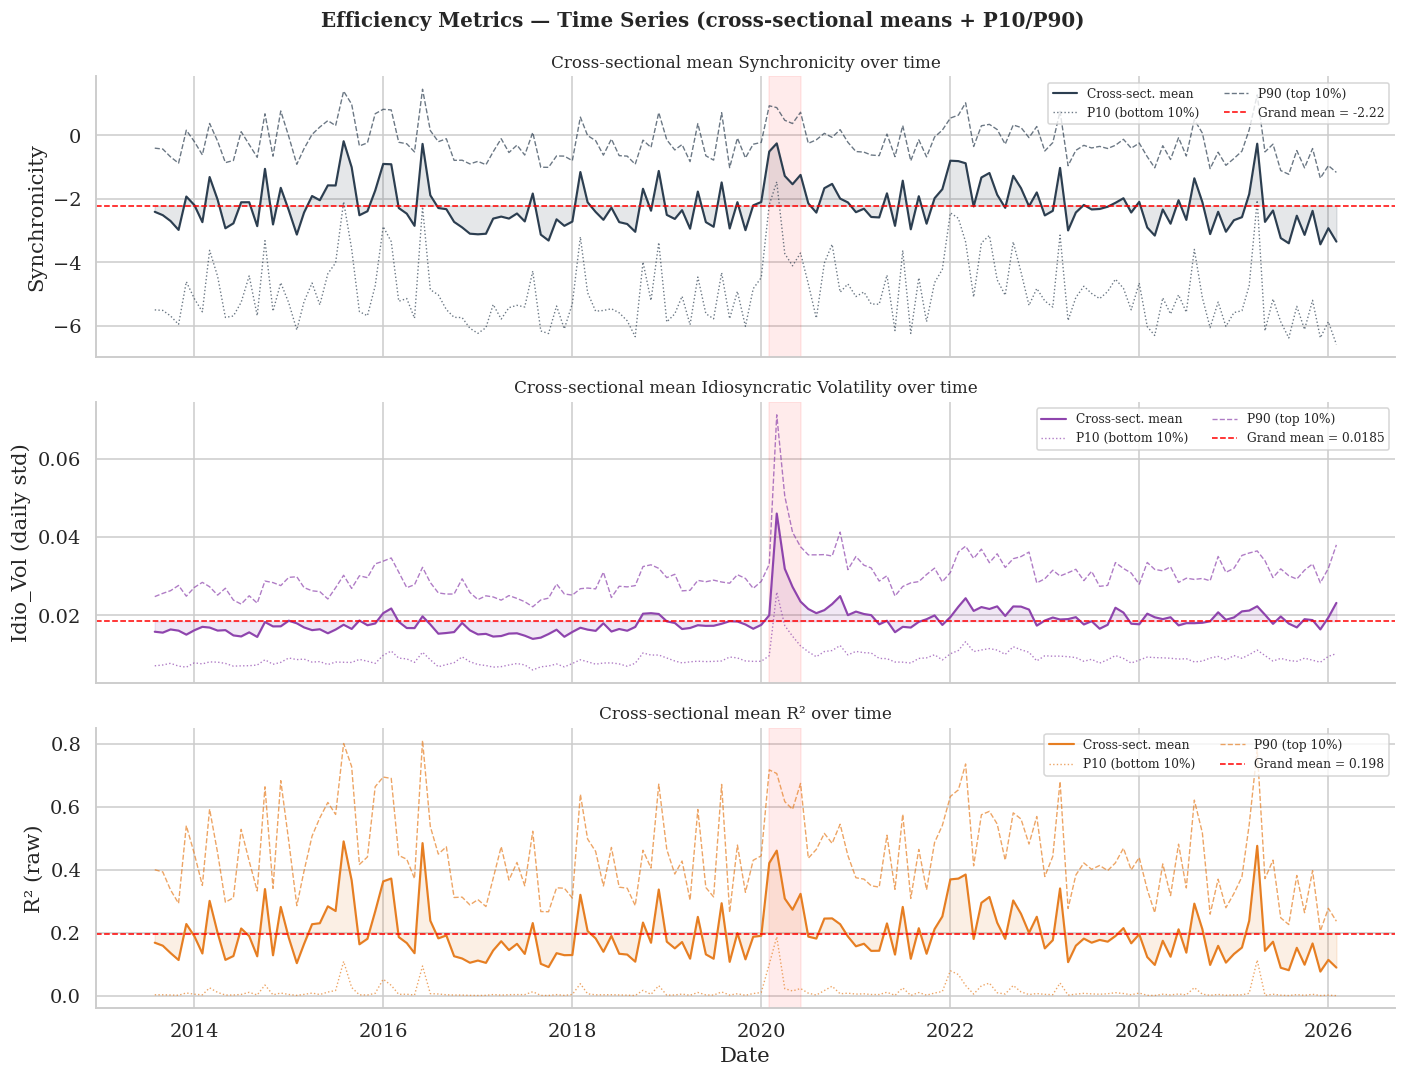

In [16]:
# Time series: mean + P10/P90 Synchronicity and Idio_Vol, R2_raw over time
monthly_mean = panel.groupby('date')[['Synchronicity', 'Idio_Vol', 'R2_raw']].mean()
monthly_p10  = panel.groupby('date')[['Synchronicity', 'Idio_Vol', 'R2_raw']].quantile(0.10)
monthly_p90  = panel.groupby('date')[['Synchronicity', 'Idio_Vol', 'R2_raw']].quantile(0.90)

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

# ── helper pour tracer chaque panneau ──────────────────────────────────────
def plot_panel(ax, col, color, title, ylabel):
    y     = monthly_mean[col]
    y_p10 = monthly_p10[col]
    y_p90 = monthly_p90[col]
    grand_mean = y.mean()

    ax.plot(y.index, y, color=color, lw=1.4, label='Cross-sect. mean')
    ax.plot(y_p10.index, y_p10, color=color, lw=0.9, linestyle=':', alpha=0.7, label='P10 (bottom 10%)')
    ax.plot(y_p90.index, y_p90, color=color, lw=0.9, linestyle='--', alpha=0.7, label='P90 (top 10%)')
    ax.fill_between(y.index, grand_mean, y, alpha=0.12, color=color)
    ax.axhline(grand_mean, color='red', lw=1, linestyle='--',
               label=f'Grand mean = {grand_mean:.3g}')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8, ncol=2)

plot_panel(axes[0], 'Synchronicity', '#2c3e50',
           'Cross-sectional mean Synchronicity over time', 'Synchronicity')
plot_panel(axes[1], 'Idio_Vol', '#8e44ad',
           'Cross-sectional mean Idiosyncratic Volatility over time', 'Idio_Vol (daily std)')
plot_panel(axes[2], 'R2_raw', '#e67e22',
           'Cross-sectional mean R² over time', 'R² (raw)')

axes[2].set_xlabel('Date')

# ── COVID shading ──────────────────────────────────────────────────────────
covid_start = pd.Timestamp('2020-02-01')
covid_end   = pd.Timestamp('2020-06-01')
for ax_ in axes:
    ax_.axvspan(covid_start, covid_end, alpha=0.08, color='red', label='COVID-19')

plt.suptitle('Efficiency Metrics — Time Series (cross-sectional means + P10/P90)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

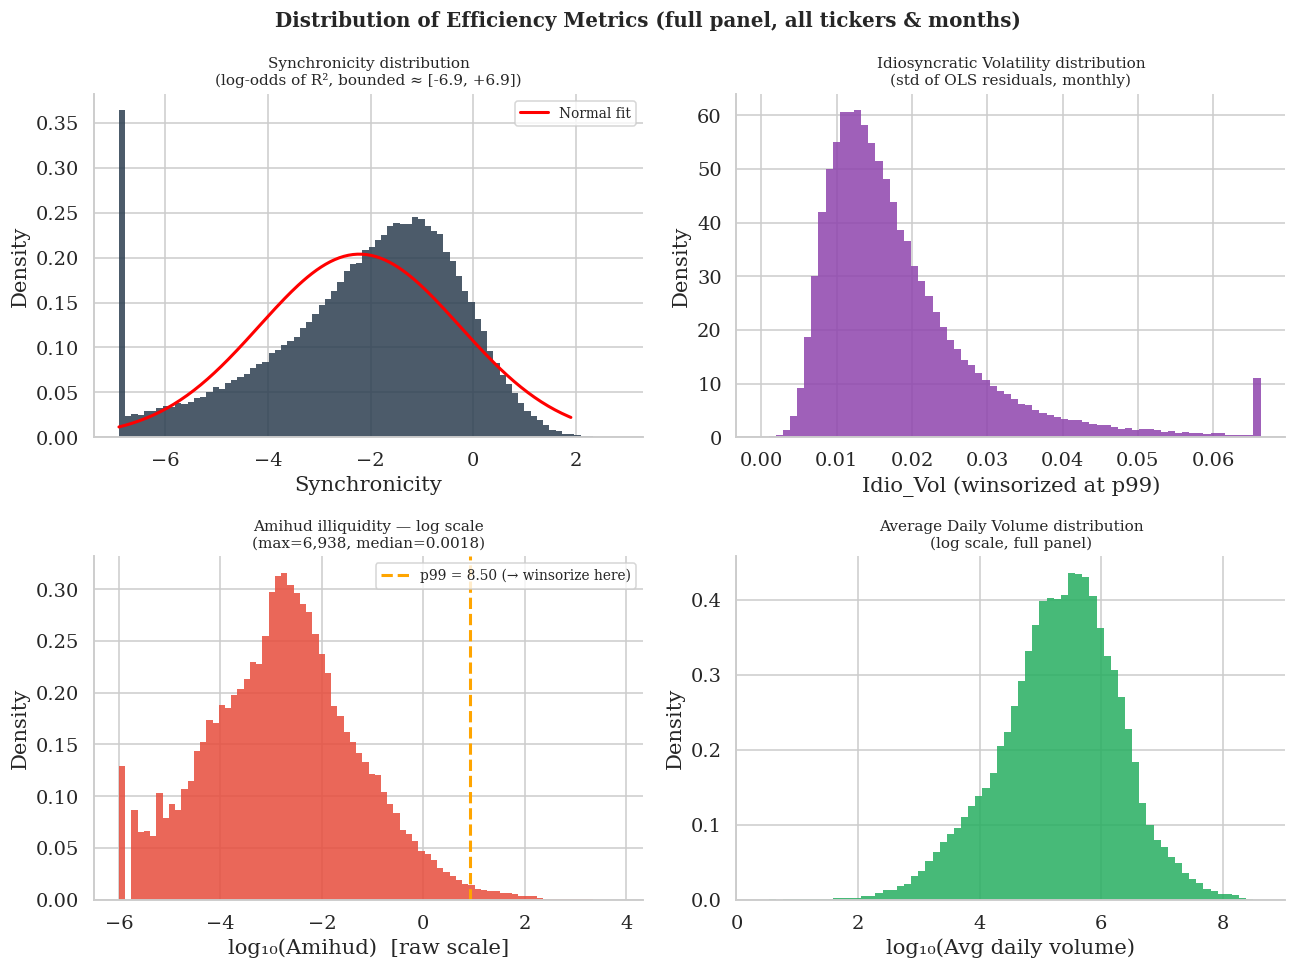

In [18]:
# Distribution of all efficiency metrics
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# 1. Synchronicity histogram
ax = axes[0, 0]
synch = panel['Synchronicity'].dropna()
ax.hist(synch, bins=80, color='#2c3e50', edgecolor='none', alpha=0.85, density=True)
# Overlay normal fit
x_range = np.linspace(synch.quantile(0.001), synch.quantile(0.999), 200)
ax.plot(x_range, stats.norm.pdf(x_range, synch.mean(), synch.std()),
        color='red', lw=2, label='Normal fit')
ax.set_xlabel('Synchronicity')
ax.set_ylabel('Density')
ax.set_title('Synchronicity distribution\n(log-odds of R², bounded ≈ [-6.9, +6.9])', fontsize=10)
ax.legend(fontsize=9)

# 2. Idio_Vol — clipped at p99
ax2 = axes[0, 1]
ivol = panel['Idio_Vol'].clip(upper=panel['Idio_Vol'].quantile(0.99))
ax2.hist(ivol, bins=70, color='#8e44ad', edgecolor='none', alpha=0.85, density=True)
ax2.set_xlabel('Idio_Vol (winsorized at p99)')
ax2.set_ylabel('Density')
ax2.set_title('Idiosyncratic Volatility distribution\n(std of OLS residuals, monthly)', fontsize=10)

# 3. Amihud — log scale to show skew
ax3 = axes[1, 0]
amihud_pos = panel['Amihud'][panel['Amihud'] > 0]
log_amihud = np.log10(amihud_pos)
ax3.hist(log_amihud, bins=80, color='#e74c3c', edgecolor='none', alpha=0.85, density=True)
p99_val = panel['Amihud'].quantile(0.99)
ax3.axvline(np.log10(p99_val), color='orange', lw=2, linestyle='--',
            label=f'p99 = {p99_val:.2f} (→ winsorize here)')
ax3.set_xlabel('log₁₀(Amihud)  [raw scale]')
ax3.set_ylabel('Density')
ax3.set_title(f'Amihud illiquidity — log scale\n(max={panel["Amihud"].max():,.0f}, median={panel["Amihud"].median():.4f})', fontsize=10)
ax3.legend(fontsize=9)

# 4. Avg_Volume — log scale
ax4 = axes[1, 1]
vol_pos = panel['Avg_Volume'][panel['Avg_Volume'] > 0]
ax4.hist(np.log10(vol_pos), bins=70, color='#27ae60', edgecolor='none', alpha=0.85, density=True)
ax4.set_xlabel('log₁₀(Avg daily volume)')
ax4.set_ylabel('Density')
ax4.set_title('Average Daily Volume distribution\n(log scale, full panel)', fontsize=10)

plt.suptitle('Distribution of Efficiency Metrics (full panel, all tickers & months)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

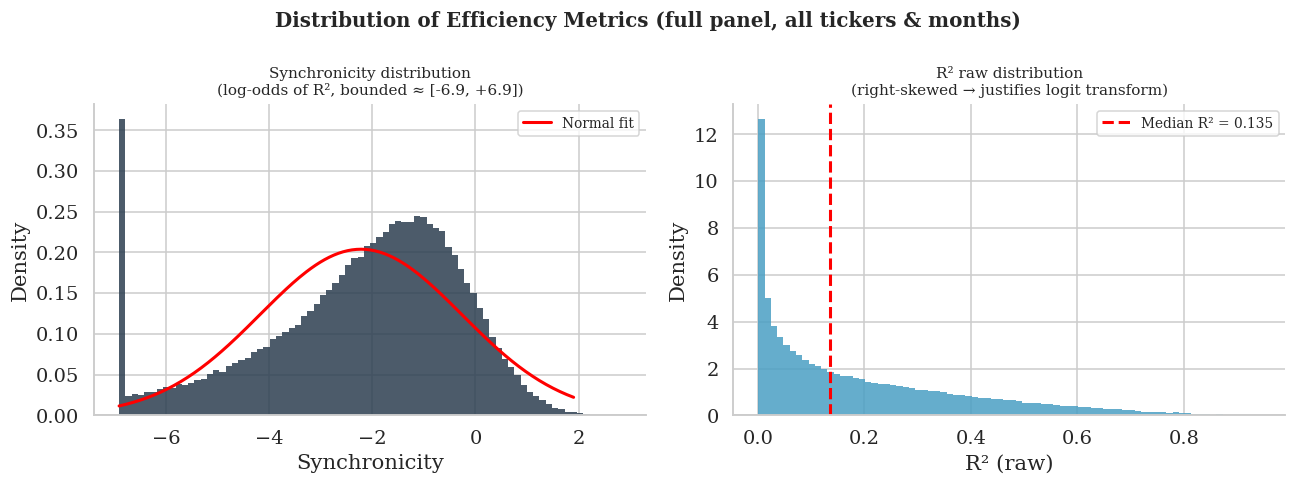

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# 1. Synchronicity
ax1 = axes[0]
synch = panel['Synchronicity'].dropna()
ax1.hist(synch, bins=80, color='#2c3e50', edgecolor='none', alpha=0.85, density=True)
x_range = np.linspace(synch.quantile(0.001), synch.quantile(0.999), 200)
ax1.plot(x_range, stats.norm.pdf(x_range, synch.mean(), synch.std()),
         color='red', lw=2, label='Normal fit')
ax1.set_xlabel('Synchronicity')
ax1.set_ylabel('Density')
ax1.set_title('Synchronicity distribution\n(log-odds of R², bounded ≈ [-6.9, +6.9])', fontsize=10)
ax1.legend(fontsize=9)

# 2. R² brut
ax2 = axes[1]
r2_raw = 1 / (1 + np.exp(-synch))  # inverse logit : R² = e^s / (1 + e^s)
ax2.hist(r2_raw, bins=80, color='#4a9fc4', edgecolor='none', alpha=0.85, density=True)
median_r2 = r2_raw.median()
ax2.axvline(median_r2, color='red', lw=2, linestyle='--',
            label=f'Median R² = {median_r2:.3f}')
ax2.set_xlabel('R² (raw)')
ax2.set_ylabel('Density')
ax2.set_title('R² raw distribution\n(right-skewed → justifies logit transform)', fontsize=10)
ax2.legend(fontsize=9)

plt.suptitle('Distribution of Efficiency Metrics (full panel, all tickers & months)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('distribution_synch_r2.png', dpi=180, bbox_inches='tight')
plt.show()

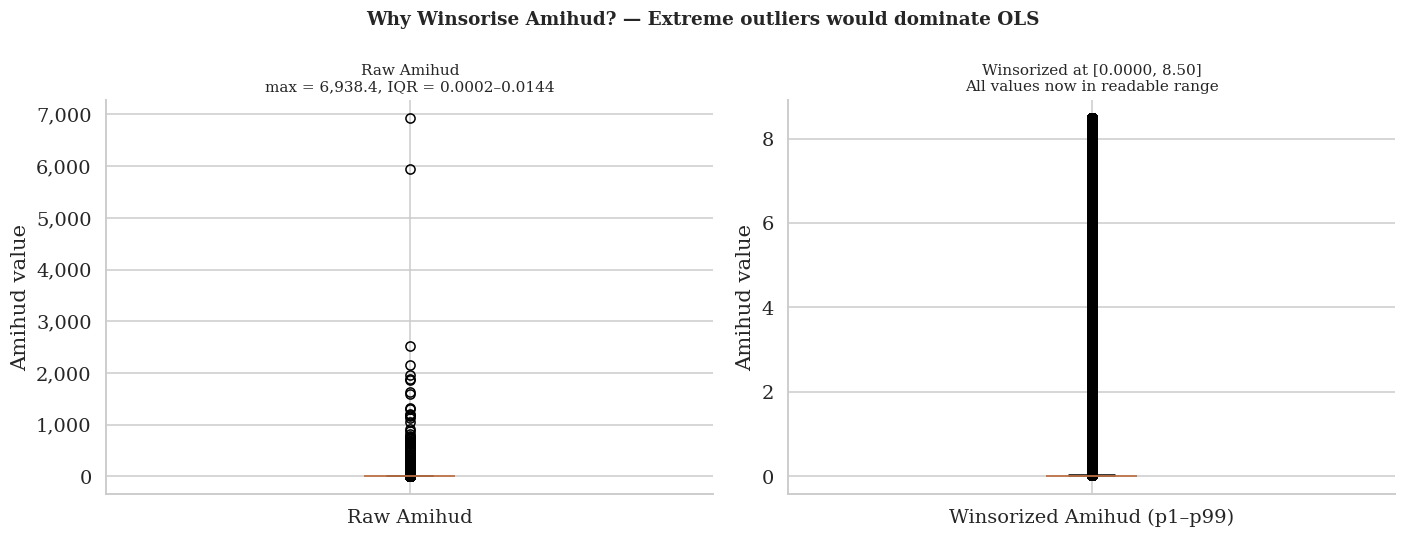

In [36]:
# Why winsorise Amihud? — visual illustration
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

amihud = panel['Amihud'].dropna()
p01 = amihud.quantile(0.01)
p99 = amihud.quantile(0.99)
amihud_w = amihud.clip(p01, p99)

ax = axes[0]
ax.boxplot([amihud.values], labels=['Raw Amihud'], patch_artist=True,
           boxprops=dict(facecolor='#f39c12', alpha=0.7))
ax.set_ylabel('Amihud value')
ax.set_title(f'Raw Amihud\nmax = {amihud.max():,.1f}, IQR = {amihud.quantile(0.25):.4f}–{amihud.quantile(0.75):.4f}', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

ax2 = axes[1]
ax2.boxplot([amihud_w.values], labels=['Winsorized Amihud (p1–p99)'], patch_artist=True,
            boxprops=dict(facecolor='#2ecc71', alpha=0.7))
ax2.set_ylabel('Amihud value')
ax2.set_title(f'Winsorized at [{p01:.4f}, {p99:.2f}]\nAll values now in readable range', fontsize=10)

plt.suptitle('Why Winsorise Amihud? — Extreme outliers would dominate OLS', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

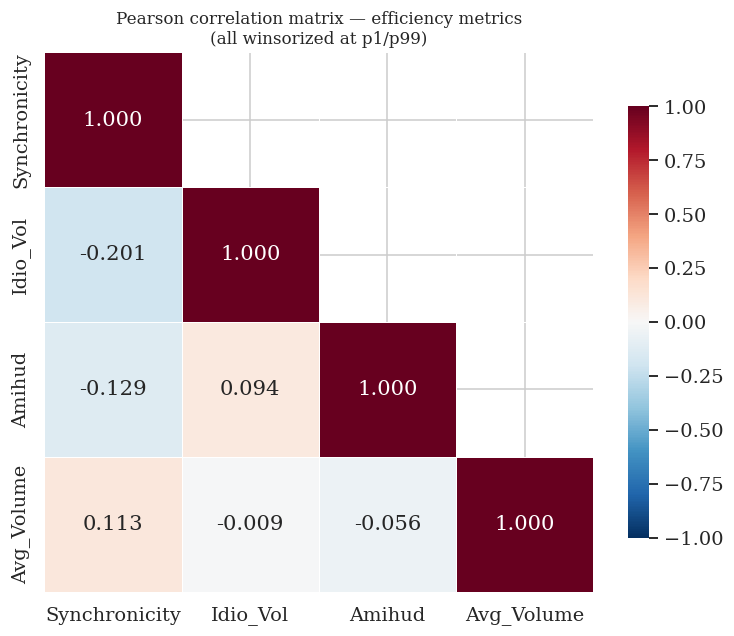

Note: Synchronicity and Idio_Vol are negatively correlated by construction
  corr(Sync, Idio_Vol) = -0.201


In [37]:
# Correlation heatmap of efficiency metrics (winsorised)
metrics = ['Synchronicity', 'Idio_Vol', 'Amihud', 'Avg_Volume']
panel_w = panel[metrics].copy()
for col in metrics:
    p01c = panel_w[col].quantile(0.01)
    p99c = panel_w[col].quantile(0.99)
    panel_w[col] = panel_w[col].clip(p01c, p99c)

corr = panel_w.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, mask=mask, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Pearson correlation matrix — efficiency metrics\n(all winsorized at p1/p99)', fontsize=11)
plt.tight_layout()
plt.show()

print('Note: Synchronicity and Idio_Vol are negatively correlated by construction')
print(f'  corr(Sync, Idio_Vol) = {corr.loc["Synchronicity","Idio_Vol"]:.3f}')

---
## Part 5 — PSM Feature Space

Propensity Score Matching requires pre-treatment characteristics that predict treatment (index inclusion) **without being caused by it**. For each ADD event date, a 12-month pre-event window is used to compute three features for the treated firm and every potential control ticker:

| Feature | Construction | Why it matters |
|---------|-------------|----------------|
| **Log_MarketCap** | $\ln(P \times \bar{V})$ | STOXX selects large-caps; must control for size |
| **Momentum_12m** | $\ln(P_{end}/P_{start})$ | STOXX tends to add recent outperformers |
| **Volatility_pre** | $\sigma(\text{daily returns})$ | Risk profile differs across size strata |

**Matching pool:** ~10,400 potential controls per event → extremely rich pool for 1:1 PSM.

In [38]:
print('=== PSM Features — Descriptive Statistics ===')
feat_cols = ['Log_MarketCap', 'Momentum_12m', 'Volatility_pre']
desc_feat = features[feat_cols + ['treated']].groupby('treated').describe(
    percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]
).round(4)
display(desc_feat)

=== PSM Features — Descriptive Statistics ===


Log_MarketCap                                                       \
                count     mean     std      min       5%      25%      50%   
treated                                                                      
0            894195.0  16.3972  2.9903   5.6474  11.6063  14.3281  16.1626   
1               671.0  17.5821  2.0131  13.9542  14.9162  15.8897  17.2080   

                                    ... Volatility_pre                  \
             75%      95%      max  ...          count    mean     std   
treated                             ...                                  
0        18.5153  21.5669  25.5345  ...       894195.0  0.0239  0.0126   
1        19.7177  20.7705  22.3528  ...          671.0  0.0242  0.0105   

                                                                 
            min      5%     25%     50%     75%     95%     max  
treated                                                          
0        0.0050  0.0119  0.0167  0.0212  0.0276  0.0435  0.2572  
1        0.0072  0.0122  0.0179  0.0225  0.0287  0.0409  0.1201  

[2 rows x 30 columns]

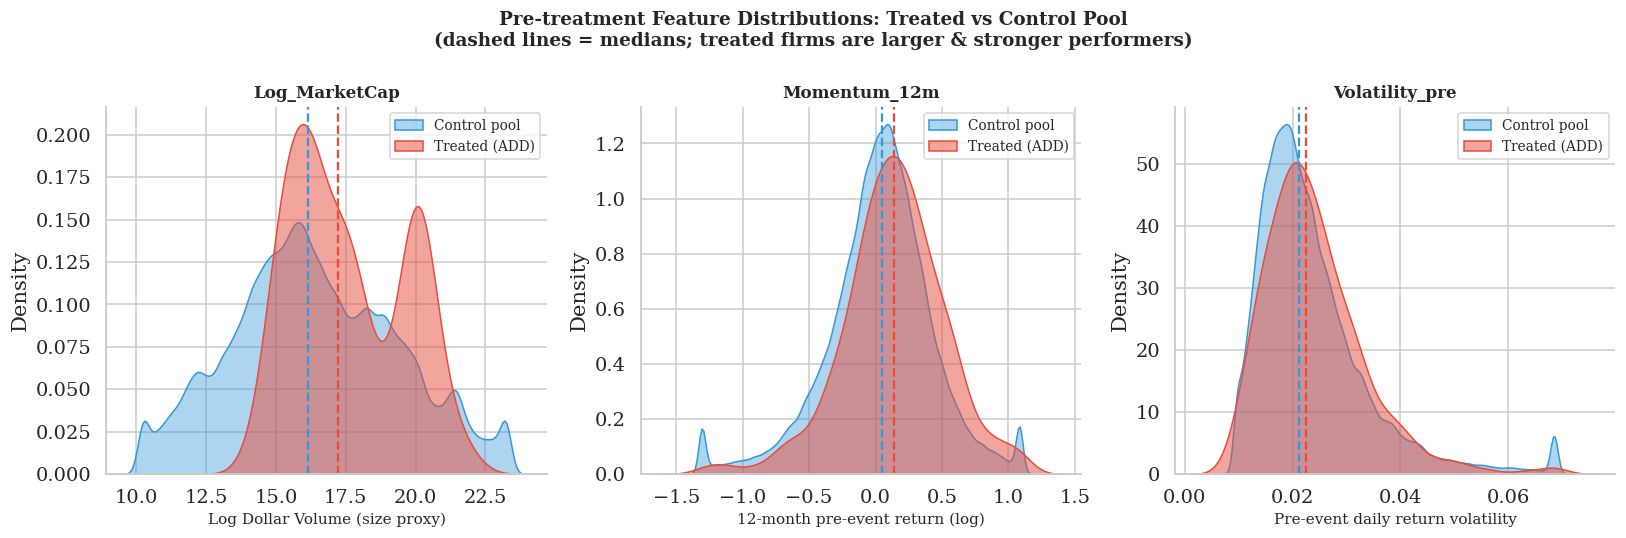

In [39]:
# KDE: treated vs control pool for each feature
treated_df = features[features['treated'] == 1]
control_df = features[features['treated'] == 0]

labels_map = {
    'Log_MarketCap' : 'Log Dollar Volume (size proxy)',
    'Momentum_12m'  : '12-month pre-event return (log)',
    'Volatility_pre': 'Pre-event daily return volatility',
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, feat_cols):
    # Clip for display
    lo = features[col].quantile(0.01)
    hi = features[col].quantile(0.99)
    t_vals = treated_df[col].clip(lo, hi).dropna()
    c_vals = control_df[col].clip(lo, hi).dropna()

    sns.kdeplot(c_vals, ax=ax, fill=True, color='#3498db', alpha=0.4, label='Control pool')
    sns.kdeplot(t_vals, ax=ax, fill=True, color='#e74c3c', alpha=0.5, label='Treated (ADD)')

    ax.axvline(t_vals.median(), color='#e74c3c', lw=1.5, linestyle='--')
    ax.axvline(c_vals.median(), color='#3498db', lw=1.5, linestyle='--')

    ax.set_xlabel(labels_map[col], fontsize=10)
    ax.set_ylabel('Density')
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Pre-treatment Feature Distributions: Treated vs Control Pool\n'
             '(dashed lines = medians; treated firms are larger & stronger performers)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

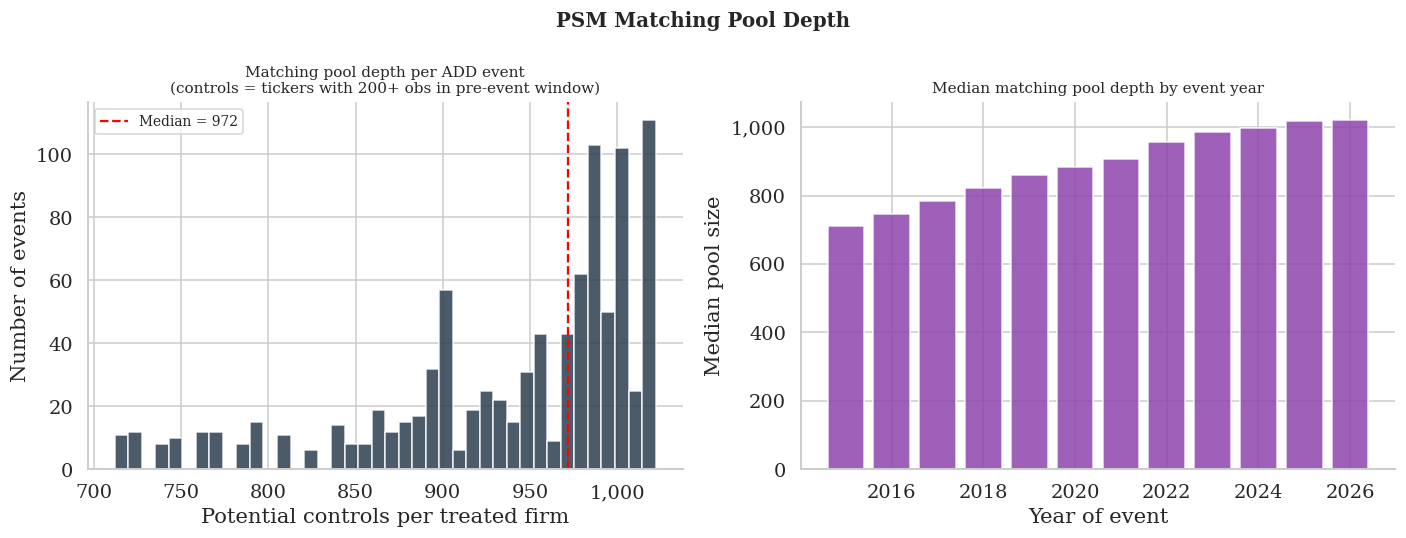

In [40]:
# Pool size per event — how many controls are available for each treated firm?
pool_size = features.groupby(['event_date', 'ticker_treated']).size().reset_index(name='pool_size')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.hist(pool_size['pool_size'], bins=40, color='#2c3e50', edgecolor='white', alpha=0.85)
ax.axvline(pool_size['pool_size'].median(), color='red', lw=1.5, linestyle='--',
           label=f'Median = {pool_size["pool_size"].median():,.0f}')
ax.set_xlabel('Potential controls per treated firm')
ax.set_ylabel('Number of events')
ax.set_title('Matching pool depth per ADD event\n(controls = tickers with 200+ obs in pre-event window)', fontsize=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(fontsize=9)

ax2 = axes[1]
pool_by_year = pool_size.copy()
pool_by_year['year'] = pool_by_year['event_date'].dt.year
pool_mean = pool_by_year.groupby('year')['pool_size'].median()
ax2.bar(pool_mean.index, pool_mean.values, color='#8e44ad', edgecolor='white', alpha=0.85)
ax2.set_xlabel('Year of event')
ax2.set_ylabel('Median pool size')
ax2.set_title('Median matching pool depth by event year', fontsize=10)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('PSM Matching Pool Depth', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

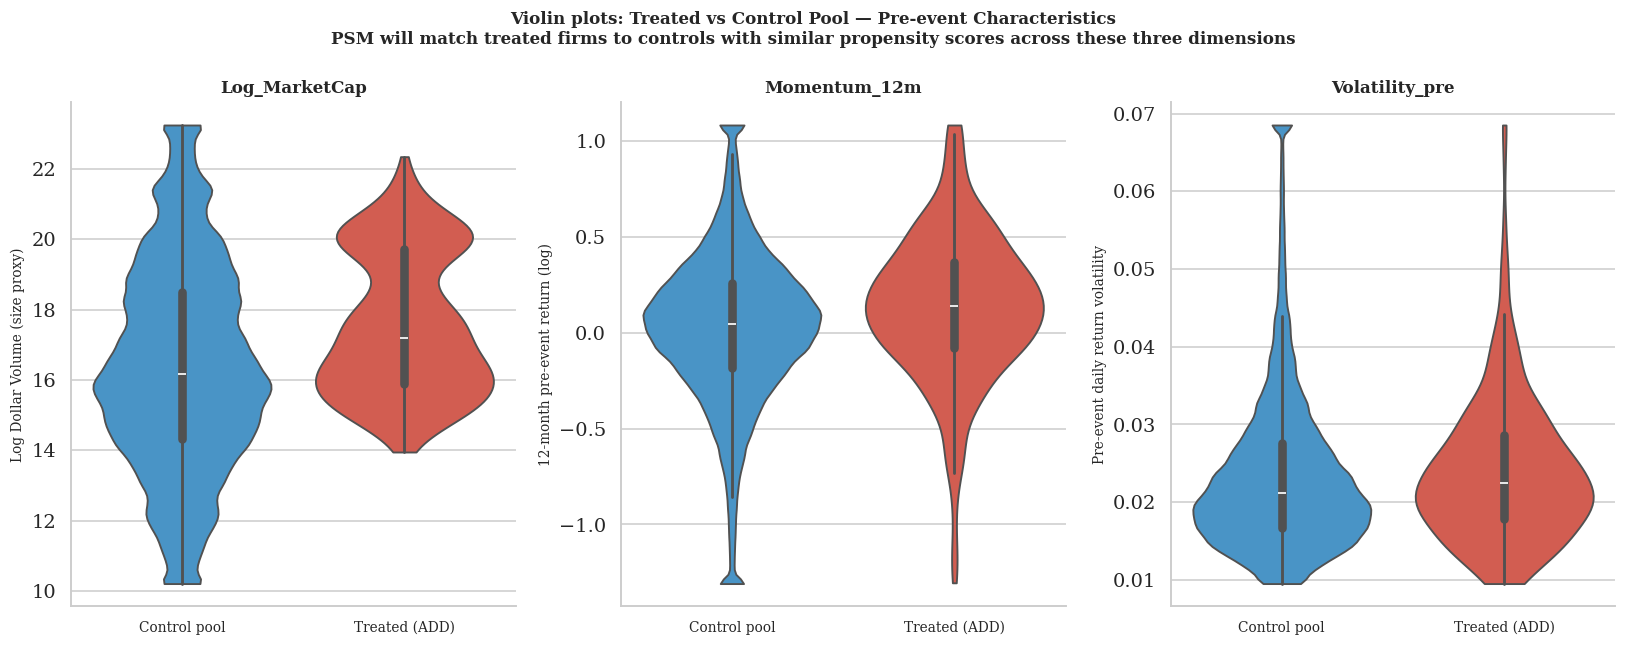

In [41]:
# Side-by-side: treated vs control on all three features — violin plot
feat_long = features[feat_cols + ['treated']].melt(
    id_vars='treated', value_vars=feat_cols, var_name='feature', value_name='value'
)
# Clip to p1-p99 per feature for display
for col in feat_cols:
    lo = features[col].quantile(0.01)
    hi = features[col].quantile(0.99)
    mask = feat_long['feature'] == col
    feat_long.loc[mask, 'value'] = feat_long.loc[mask, 'value'].clip(lo, hi)

feat_long['group'] = feat_long['treated'].map({1: 'Treated (ADD)', 0: 'Control pool'})

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
palette = {'Treated (ADD)': '#e74c3c', 'Control pool': '#3498db'}

for ax, col in zip(axes, feat_cols):
    sub = feat_long[feat_long['feature'] == col]
    sns.violinplot(data=sub, x='group', y='value', palette=palette,
                   inner='box', ax=ax, cut=0)
    ax.set_xlabel('')
    ax.set_ylabel(labels_map[col], fontsize=9)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', labelsize=9)

plt.suptitle('Violin plots: Treated vs Control Pool — Pre-event Characteristics\n'
             'PSM will match treated firms to controls with similar propensity scores across these three dimensions',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 6 — Pipeline Summary

This section summarises all intermediate datasets and confirms data quality before running the causal analysis.

In [42]:
summary = pd.DataFrame([
    {'Dataset': 'Raw CSV files', 'Rows / Count': f'{len(raw_files)} files',
     'Key stats': f'Nov 2015 – Feb 2026 | {len(raw_files)} monthly snapshots'},
    {'Dataset': 'events.csv', 'Rows / Count': f'{len(events):,}',
     'Key stats': f'ADD={events[events["event_type"]=="ADD"].shape[0]} | DELETE={events[events["event_type"]=="DELETE"].shape[0]} | 17 countries'},
    {'Dataset': 'prices_raw.parquet', 'Rows / Count': f'{len(prices):,}',
     'Key stats': f'{prices["ticker"].nunique()} tickers | {prices["date"].min().date()} – {prices["date"].max().date()}'},
    {'Dataset': 'panel_monthly.parquet', 'Rows / Count': f'{len(panel):,}',
     'Key stats': f'{panel["ticker"].nunique()} tickers | {panel["date"].min().date()} – {panel["date"].max().date()}'},
    {'Dataset': 'features_at_event.csv', 'Rows / Count': f'{len(features):,}',
     'Key stats': f'{features["event_date"].nunique()} events | {features["treated"].sum()} treated rows | avg {len(features)//max(features["event_date"].nunique(),1):,} controls/event'},
])

display(summary.set_index('Dataset'))

# NaN / Inf check
print('\n=== Data quality: NaN and Inf counts ===')
for name, df_, cols_ in [
    ('panel_monthly', panel, ['Synchronicity', 'Idio_Vol', 'Amihud', 'Avg_Volume']),
    ('features_at_event', features, ['Log_MarketCap', 'Momentum_12m', 'Volatility_pre']),
]:
    nan_count = df_[cols_].isnull().sum().sum()
    inf_count = np.isinf(df_[cols_].select_dtypes('number')).sum().sum()
    status = '✓' if nan_count == 0 and inf_count == 0 else '✗'
    print(f'  {status}  {name}: {nan_count} NaN, {inf_count} Inf')

,Rows / Count,Key stats
Dataset,,
Raw CSV files,102 files,Nov 2015 – Feb 2026 | 102 monthly snapshots
events.csv,"1,874",ADD=953 | DELETE=921 | 17 countries
prices_raw.parquet,"2,931,958",1035 tickers | 2013-01-01 – 2026-02-27
panel_monthly.parquet,"132,652",1033 tickers | 2013-08-01 – 2026-02-01
features_at_event.csv,"894,866","82 events | 671 treated rows | avg 10,913 cont..."



=== Data quality: NaN and Inf counts ===
  ✓  panel_monthly: 0 NaN, 0 Inf
  ✓  features_at_event: 0 NaN, 0 Inf


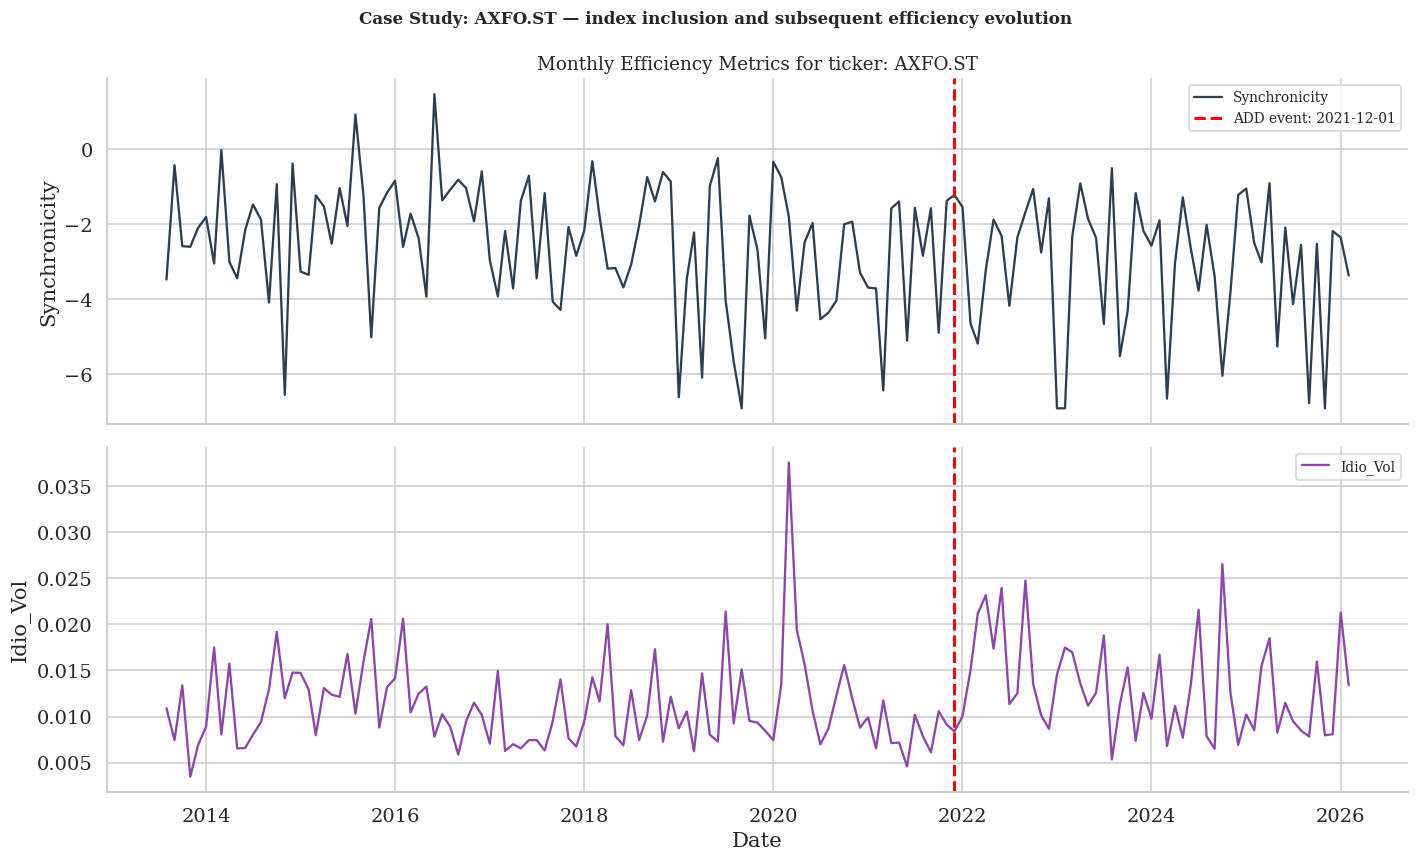

Ticker: AXFO.ST | Event date: 2021-12-01
Panel observations: 151 months


In [43]:
# Final visual: what the panel looks like for one sample stock
# Pick a well-covered treated ticker
treated_tickers = events[events['event_type'] == 'ADD']['ticker'].unique()
covered = [t for t in treated_tickers if t in panel['ticker'].values]

if covered:
    sample_ticker = covered[len(covered) // 2]  # middle of the list
    sample_ev = events[(events['ticker'] == sample_ticker) & (events['event_type'] == 'ADD')].iloc[0]
    ev_date = pd.Timestamp(sample_ev['date'])

    sub = panel[panel['ticker'] == sample_ticker].sort_values('date')

    fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

    ax = axes[0]
    ax.plot(sub['date'], sub['Synchronicity'], color='#2c3e50', lw=1.5, label='Synchronicity')
    ax.axvline(ev_date, color='red', lw=2, linestyle='--', label=f'ADD event: {ev_date.date()}')
    ax.set_ylabel('Synchronicity')
    ax.set_title(f'Monthly Efficiency Metrics for ticker: {sample_ticker}', fontsize=12)
    ax.legend(fontsize=9)

    ax2 = axes[1]
    ax2.plot(sub['date'], sub['Idio_Vol'], color='#8e44ad', lw=1.5, label='Idio_Vol')
    ax2.axvline(ev_date, color='red', lw=2, linestyle='--')
    ax2.set_ylabel('Idio_Vol')
    ax2.set_xlabel('Date')
    ax2.legend(fontsize=9)

    plt.suptitle(f'Case Study: {sample_ticker} — index inclusion and subsequent efficiency evolution',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(f'Ticker: {sample_ticker} | Event date: {ev_date.date()}')
    print(f'Panel observations: {len(sub)} months')

---
## Conclusion

This notebook has shown:

1. **Raw data:** 126 monthly STOXX snapshots, many affected by PDF parsing artifacts that would have inflated the event count from ~1,800 to >13,000 without cleaning.

2. **Events:** After cleaning, **953 ADD / 921 DELETE events** — an almost perfect 1:1 ratio, consistent with the mechanics of a fixed-size index. Events span 17 European countries, with France, Germany, and Sweden leading.

3. **Price data:** 126,000+ daily observations across 989 tickers, with strong coverage (most markets >90%) after ticker remapping.

4. **Efficiency panel:** Monthly OLS regressions produce four clean metrics. Synchronicity is normally distributed; Amihud is extremely right-skewed (max/median ≈ 4,000,000×) and **will be winsorised at runtime** before estimation.

5. **PSM features:** Treated firms are visibly larger (higher Log_MarketCap) and had stronger recent returns (Momentum_12m), confirming the need for matching. The control pool averages **~10,400 firms per event**, giving PSM excellent resolution.

**Next step:** Run `scripts/analysis/01_matching.py` → `02_did_estimation.py` → `03_event_study.py`